In [1]:
!pip install -q xgboost imbalanced-learn seaborn joblib

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Disease_dataset.zip"
extract_path = "/content/Disease_Dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully!")

print("\nFiles:")
print(os.listdir(extract_path))

Dataset Extracted Successfully!

Files:
['diets.csv', 'precautions.csv', 'medications.csv', 'description.csv', 'workout.csv', 'Diseases_and_Symptoms_dataset.csv']


In [4]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

from xgboost import XGBClassifier

plt.style.use("ggplot")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [5]:
dataset = pd.read_csv(
    os.path.join(extract_path, "Diseases_and_Symptoms_dataset.csv")
)

description = pd.read_csv(
    os.path.join(extract_path, "description.csv")
)

diets = pd.read_csv(
    os.path.join(extract_path, "diets.csv")
)

medications = pd.read_csv(
    os.path.join(extract_path, "medications.csv")
)

precautions = pd.read_csv(
    os.path.join(extract_path, "precautions.csv")
)

workout = pd.read_csv(
    os.path.join(extract_path, "workout.csv")
)

print("Main Dataset Shape:", dataset.shape)

Main Dataset Shape: (96088, 231)


In [6]:
print("Shape :", dataset.shape)

print("\nColumns :", len(dataset.columns))

print("\nFirst Five Rows")
display(dataset.head())

print("\nDataset Info")
display(dataset.info())

print("\nMissing Values")
display(dataset.isnull().sum().sort_values(ascending=False).head(15))

print("\nDuplicate Rows :", dataset.duplicated().sum())

Shape : (96088, 231)

Columns : 231

First Five Rows


,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,sneezing,leg weakness,hysterical behavior,arm lump or mass,bleeding gums,pain in gums,diaper rash,hesitancy,back stiffness or tightness,low urine output
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0



Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96088 entries, 0 to 96087
Columns: 231 entries, diseases to low urine output
dtypes: int64(230), object(1)
memory usage: 169.3+ MB


None


Missing Values


,0
diseases,0
anxiety and nervousness,0
depression,0
shortness of breath,0
depressive or psychotic symptoms,0
sharp chest pain,0
dizziness,0
insomnia,0
abnormal involuntary movements,0
chest tightness,0



Duplicate Rows : 0


In [7]:
print("Number of Diseases:", dataset['diseases'].nunique())

print("\nTop Diseases")

display(dataset['diseases'].value_counts().head(15))

Number of Diseases: 100

Top Diseases


,count
diseases,
cystitis,1219
vulvodynia,1218
nose disorder,1218
complex regional pain syndrome,1217
spondylosis,1216
vaginal cyst,1215
conjunctivitis due to allergy,1215
peripheral nerve disorder,1215
esophagitis,1215


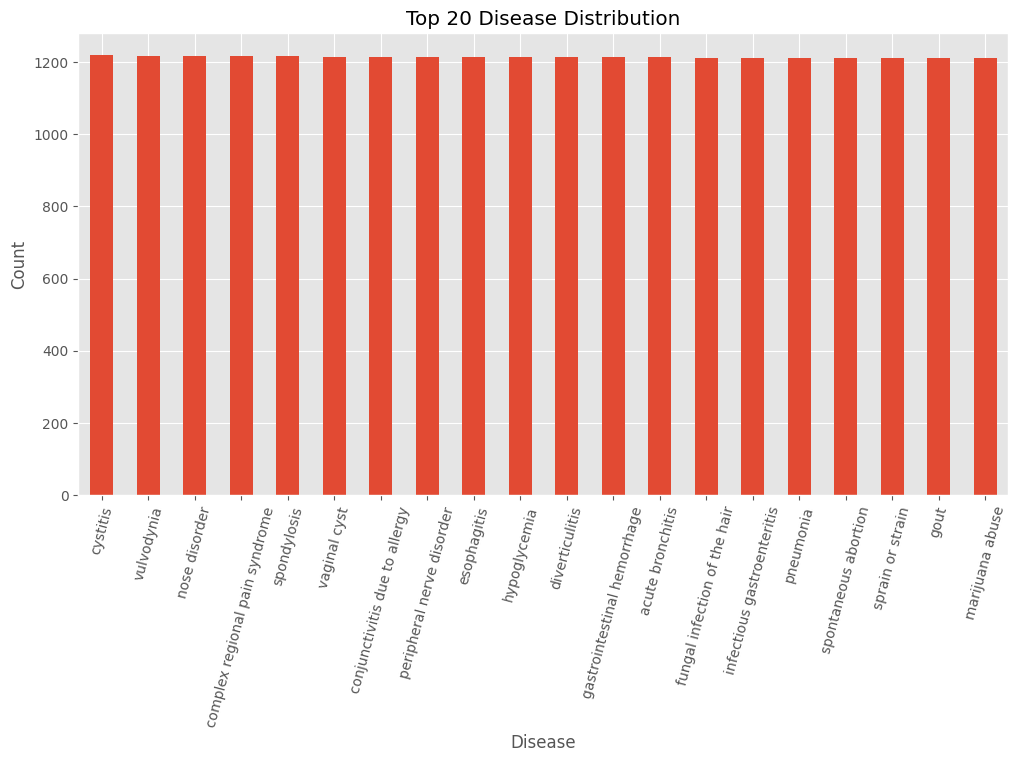

In [8]:
plt.figure(figsize=(12,6))

dataset['diseases'].value_counts().head(20).plot(kind='bar')

plt.title("Top 20 Disease Distribution")
plt.xlabel("Disease")
plt.ylabel("Count")

plt.xticks(rotation=75)

plt.show()

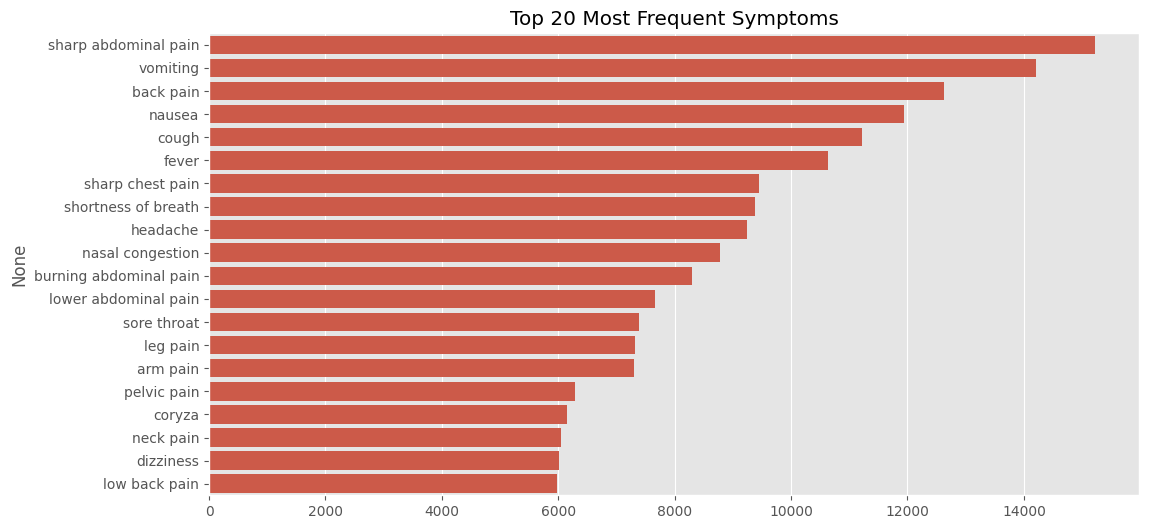

In [9]:
symptom_columns = dataset.columns.drop("diseases")

symptom_frequency = dataset[symptom_columns].sum()

top20 = symptom_frequency.sort_values(
    ascending=False
).head(20)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top20.values,
    y=top20.index
)

plt.title("Top 20 Most Frequent Symptoms")

plt.show()

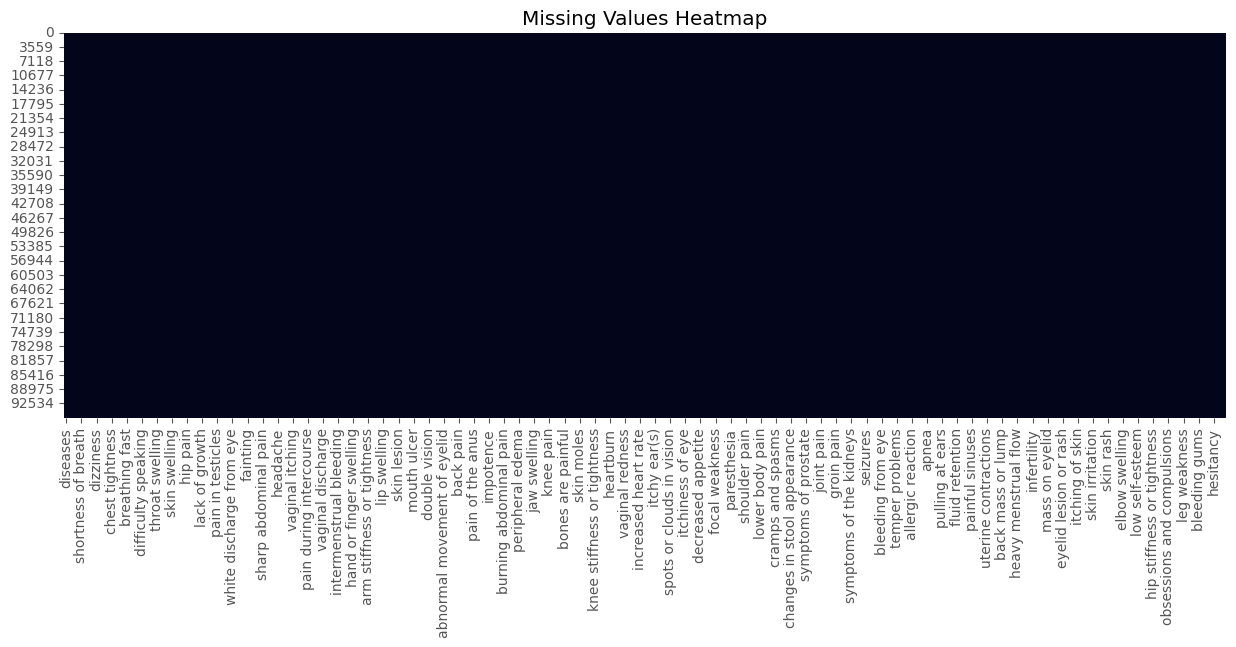

In [10]:
plt.figure(figsize=(15,5))

sns.heatmap(
    dataset.isnull(),
    cbar=False
)

plt.title("Missing Values Heatmap")

plt.show()

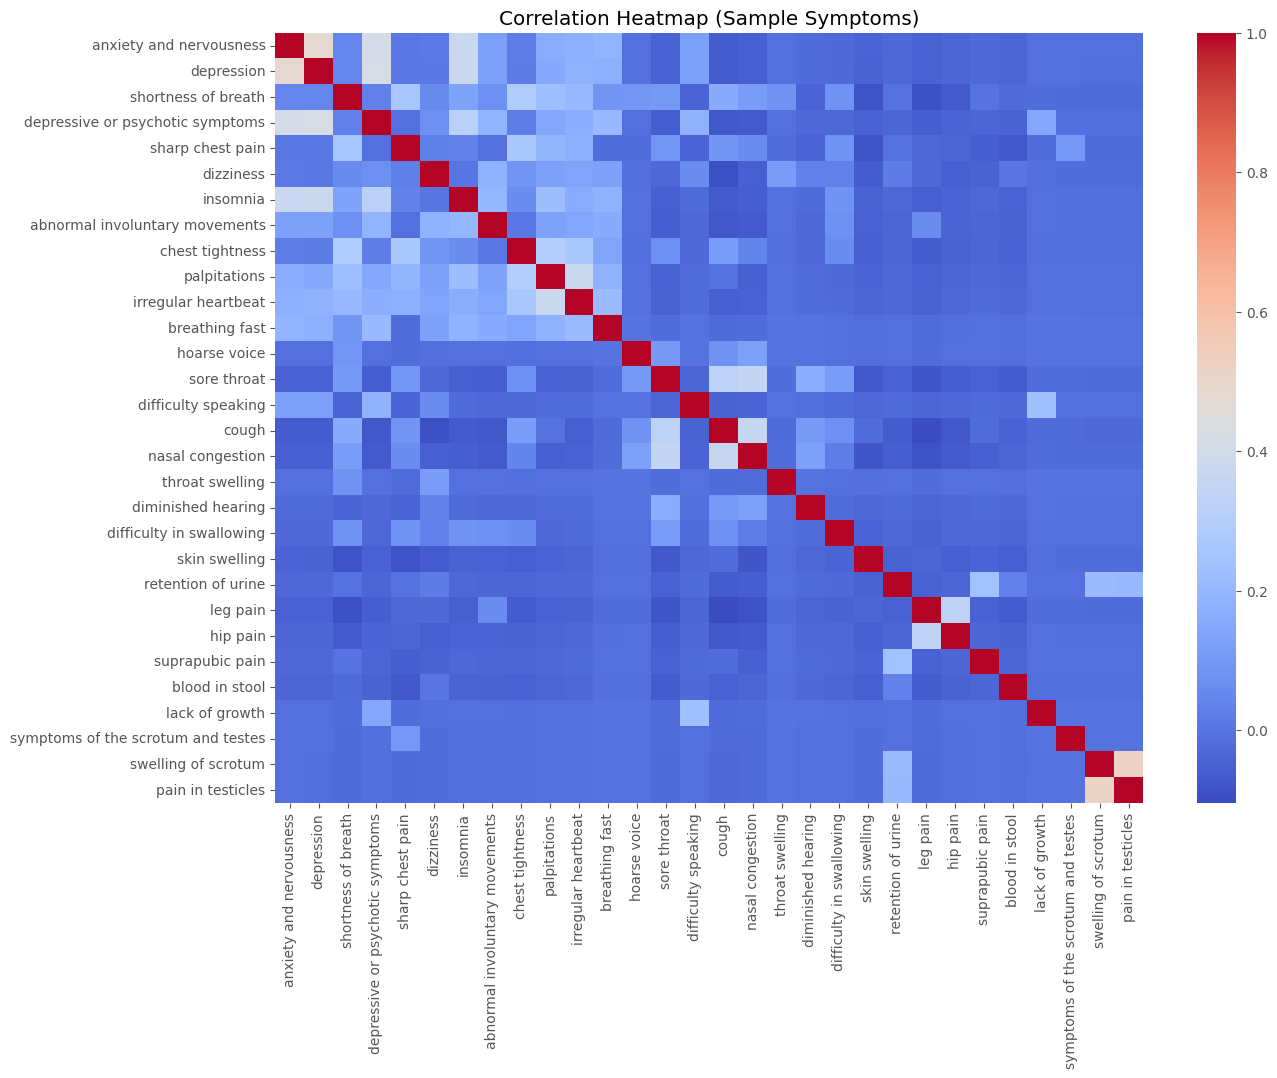

In [11]:
plt.figure(figsize=(14,10))

corr = dataset.iloc[:,1:31].corr()

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap (Sample Symptoms)")

plt.show()

In [12]:
from sklearn.preprocessing import LabelEncoder

# Encode target labels
label_encoder = LabelEncoder()

dataset['disease_encoded'] = label_encoder.fit_transform(dataset['diseases'])

print("Number of Diseases :", len(label_encoder.classes_))

print("\nSample Classes:")

for i in range(10):
    print(i, "->", label_encoder.classes_[i])

Number of Diseases : 100

Sample Classes:
0 -> actinic keratosis
1 -> acute bronchiolitis
2 -> acute bronchitis
3 -> acute bronchospasm
4 -> acute kidney injury
5 -> acute pancreatitis
6 -> acute sinusitis
7 -> allergy
8 -> angina
9 -> anxiety


In [13]:
X = dataset.drop(columns=['diseases','disease_encoded'])

y = dataset['disease_encoded']

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (96088, 230)
Target Shape : (96088,)


In [14]:
from sklearn.model_selection import train_test_split

# First split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Validation + Testing

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training :", X_train.shape)
print("Validation :", X_val.shape)
print("Testing :", X_test.shape)

Training : (67261, 230)
Validation : (14413, 230)
Testing : (14414, 230)


In [15]:
print("Training Class Distribution")

print(y_train.value_counts().head())

print("\nValidation Class Distribution")

print(y_val.value_counts().head())

print("\nTesting Class Distribution")

print(y_test.value_counts().head())

Training Class Distribution
disease_encoded
99    853
66    853
29    853
22    852
89    851
Name: count, dtype: int64

Validation Class Distribution
disease_encoded
29    183
22    182
91    182
43    182
73    182
Name: count, dtype: int64

Testing Class Distribution
disease_encoded
89    183
22    183
29    183
99    183
25    183
Name: count, dtype: int64


In [16]:
from xgboost import XGBClassifier

baseline_model = XGBClassifier(

    objective='multi:softprob',

    eval_metric='mlogloss',

    tree_method='hist',

    random_state=42,

    use_label_encoder=False

)

baseline_model.fit(X_train,y_train)

print("Baseline Model Trained Successfully")

Baseline Model Trained Successfully


In [17]:
from sklearn.metrics import accuracy_score

val_prediction = baseline_model.predict(X_val)

baseline_accuracy = accuracy_score(
    y_val,
    val_prediction
)

print("Baseline Validation Accuracy : {:.4f}".format(
    baseline_accuracy
))

Baseline Validation Accuracy : 0.8680


In [18]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

param_grid = {
    'n_estimators': [150, 200, 250],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    tree_method='hist',
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=5,          # Reduced from 20
    scoring='accuracy',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=1           # Changed from -1
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best CV Accuracy:", random_search.best_score_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, n_estimators=250, subsample=0.8; total time= 5.8min
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, n_estimators=250, subsample=0.8; total time= 5.9min
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, n_estimators=250, subsample=0.8; total time= 5.7min
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=6, n_estimators=200, subsample=0.8; total time= 6.2min
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=6, n_estimators=200, subsample=0.8; total time= 6.7min
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=6, n_estimators=200, subsample=0.8; total time= 6.4min
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=4, n_estimators=150, subsample=0.8; total time= 3.5min
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=4, n_estimators=150, subsample=0.8; total time= 3.5min
[CV] END colsampl

In [19]:
print("="*50)
print("Best Hyperparameters")
print("="*50)

print(random_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(f"{random_search.best_score_:.4f}")

Best Hyperparameters
{'subsample': 0.8, 'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

Best Cross Validation Accuracy:
0.8843


In [20]:
best_model = random_search.best_estimator_

print(best_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, ...)


In [21]:
best_model.fit(X_train, y_train)

print("Best Model Training Completed.")

Best Model Training Completed.


In [22]:
train_pred = best_model.predict(X_train)
val_pred = best_model.predict(X_val)
test_pred = best_model.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, train_pred)
val_acc = accuracy_score(y_val, val_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Training Accuracy  :", round(train_acc,4))
print("Validation Accuracy:", round(val_acc,4))
print("Testing Accuracy   :", round(test_acc,4))

Training Accuracy  : 0.9128
Validation Accuracy: 0.8899
Testing Accuracy   : 0.888


In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(
    y_test,
    test_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    test_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    test_pred,
    average='weighted'
)

print("Precision :", round(precision,4))
print("Recall    :", round(recall,4))
print("F1 Score  :", round(f1,4))

Precision : 0.8925
Recall    : 0.888
F1 Score  : 0.8891


In [25]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    test_pred,
    target_names=label_encoder.classes_
))

                                              precision    recall  f1-score   support

                           actinic keratosis       0.88      0.71      0.79       121
                         acute bronchiolitis       0.91      0.92      0.91       181
                            acute bronchitis       0.83      0.75      0.79       182
                          acute bronchospasm       0.62      0.74      0.67       122
                         acute kidney injury       0.98      0.96      0.97       121
                          acute pancreatitis       0.88      0.93      0.91       181
                             acute sinusitis       0.89      0.85      0.87       124
                                     allergy       0.94      0.93      0.94       120
                                      angina       0.96      0.97      0.96       124
                                     anxiety       0.93      0.93      0.93       180
                                appendicitis       0.

In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, test_pred)

print(cm.shape)

(100, 100)


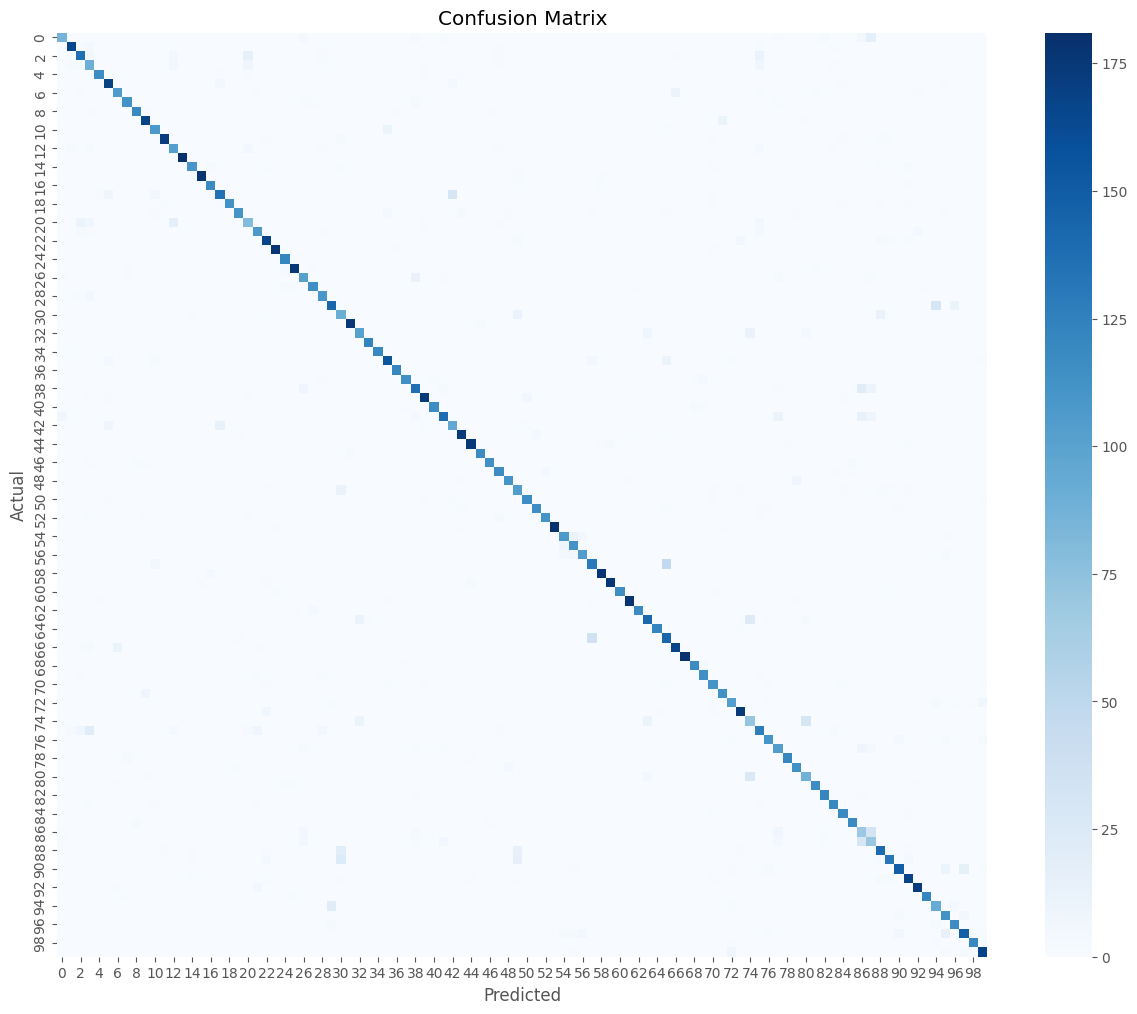

In [27]:
plt.figure(figsize=(15,12))

sns.heatmap(
    cm,
    cmap="Blues",
    cbar=True
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

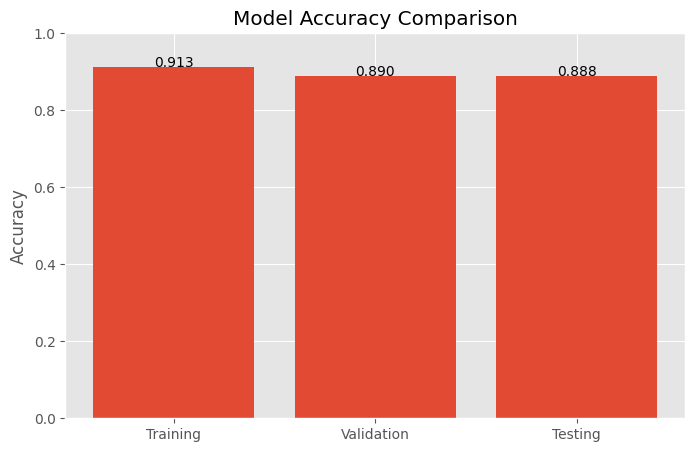

In [28]:
accuracy_scores = [train_acc,val_acc,test_acc]

labels = ["Training","Validation","Testing"]

plt.figure(figsize=(8,5))

bars = plt.bar(labels,accuracy_scores)

plt.ylim(0,1)

plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.3f}",
        ha='center'
    )

plt.show()

In [29]:
import joblib

joblib.dump(
    best_model,
    "best_xgboost_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [30]:
joblib.dump(
    label_encoder,
    "label_encoder.pkl"
)

print("Label Encoder Saved")

Label Encoder Saved


In [31]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# Probability predictions
y_prob = best_model.predict_proba(X_test)

# Convert labels to binary
y_test_bin = label_binarize(
    y_test,
    classes=np.arange(len(label_encoder.classes_))
)

roc = roc_auc_score(
    y_test_bin,
    y_prob,
    average="weighted",
    multi_class="ovr"
)

print(f"Weighted ROC-AUC Score : {roc:.4f}")

Weighted ROC-AUC Score : 0.9995


In [32]:
importance = best_model.feature_importances_

importance_df = pd.DataFrame({
    "Symptom": X.columns,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

display(importance_df.head(20))

,Symptom,Importance
144,unusual color or odor to urine,0.018559
197,eyelid lesion or rash,0.017799
27,symptoms of the scrotum and testes,0.017021
17,throat swelling,0.016289
47,pain during intercourse,0.016069
108,infant feeding problem,0.014963
170,apnea,0.014937
31,jaundice,0.014542
135,shoulder stiffness or tightness,0.014075
93,mouth dryness,0.013926


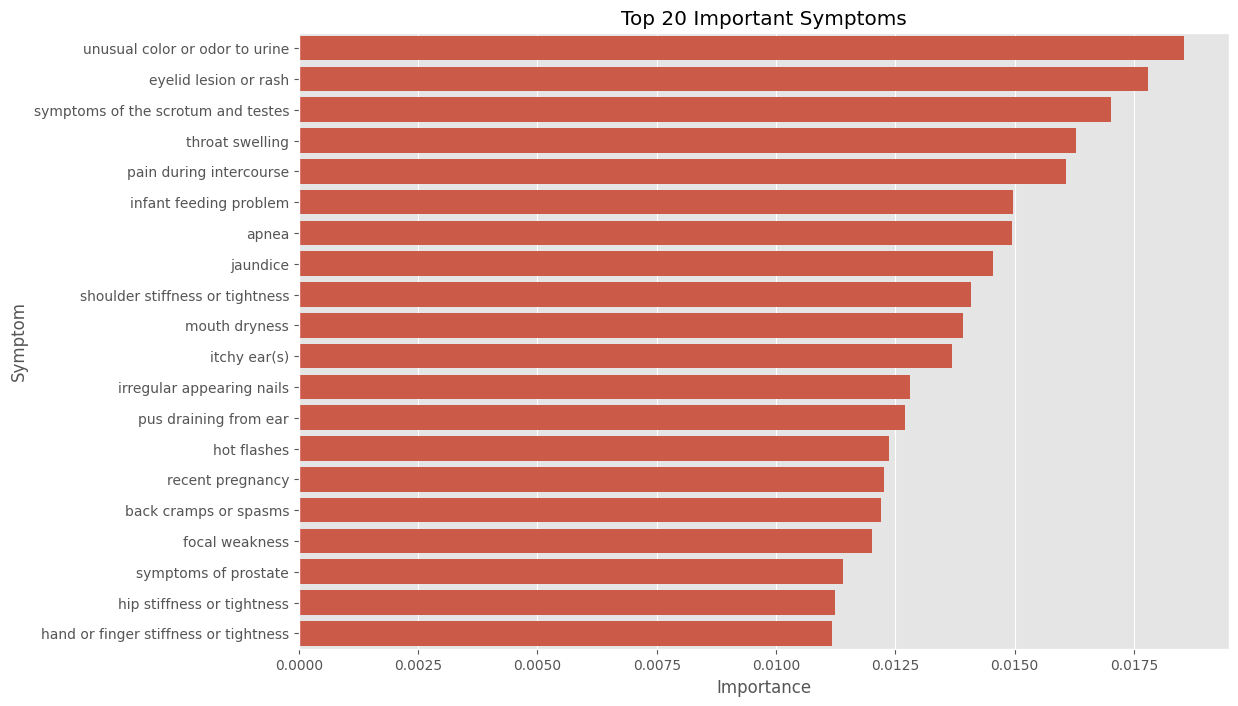

In [33]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=importance_df.head(20),
    x="Importance",
    y="Symptom"
)

plt.title("Top 20 Important Symptoms")

plt.show()

In [34]:
accuracy_df = pd.DataFrame({

    "Dataset":[
        "Training",
        "Validation",
        "Testing"
    ],

    "Accuracy":[
        train_acc,
        val_acc,
        test_acc
    ]
})

display(accuracy_df)

,Dataset,Accuracy
0,Training,0.912817
1,Validation,0.889891
2,Testing,0.887956


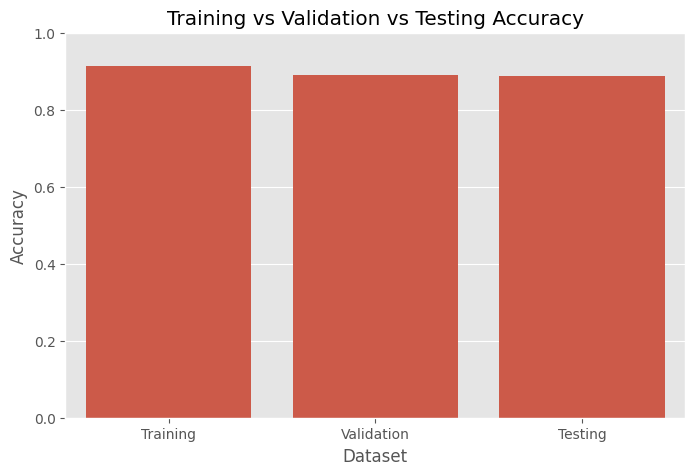

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=accuracy_df,
    x="Dataset",
    y="Accuracy"
)

plt.ylim(0,1)

plt.title("Training vs Validation vs Testing Accuracy")

plt.show()

In [36]:
import os
import joblib

save_path="/content/drive/MyDrive/Disease_Model"

os.makedirs(save_path,exist_ok=True)

joblib.dump(
    best_model,
    save_path+"/best_xgboost_model.pkl"
)

joblib.dump(
    label_encoder,
    save_path+"/label_encoder.pkl"
)

print("Saved Successfully!")

Saved Successfully!


In [38]:
 def get_cols(df):
    print(df.columns.tolist())

print("Description")
get_cols(description)

print("\nDiets")
get_cols(diets)

print("\nMedication")
get_cols(medications)

print("\nPrecautions")
get_cols(precautions)

print("\nWorkout")
get_cols(workout)

Description
['Disease', 'Description']

Diets
['Disease', 'Diet']

Medication
['Disease', 'Medication']

Precautions
['Disease', 'Precaution_1', 'Precaution_2', 'Precaution_3', 'Precaution_4']

Workout
['Disease', 'Workouts']


In [39]:
precaution_dict = {}

for _, row in precautions.iterrows():

    precaution_dict[row['Disease']] = [

        row['Precaution_1'],

        row['Precaution_2'],

        row['Precaution_3'],

        row['Precaution_4']

    ]

In [40]:
symptom_list = list(X.columns)

print("Total Symptoms:",len(symptom_list))

print(symptom_list[:20])

Total Symptoms: 230
['anxiety and nervousness', 'depression', 'shortness of breath', 'depressive or psychotic symptoms', 'sharp chest pain', 'dizziness', 'insomnia', 'abnormal involuntary movements', 'chest tightness', 'palpitations', 'irregular heartbeat', 'breathing fast', 'hoarse voice', 'sore throat', 'difficulty speaking', 'cough', 'nasal congestion', 'throat swelling', 'diminished hearing', 'difficulty in swallowing']


In [50]:
import numpy as np

def predict_disease(selected_symptoms):

    input_vector = np.zeros(len(symptom_list))

    selected_symptoms = [s.strip().lower() for s in selected_symptoms]

    for symptom in selected_symptoms:
        if symptom in symptom_list:
            idx = symptom_list.index(symptom)
            input_vector[idx] = 1

    probabilities = best_model.predict_proba([input_vector])[0]

    top3 = np.argsort(probabilities)[::-1][:3]

    print("="*75)
    print("Top 3 Predicted Diseases")
    print("="*75)

    results = []

    for rank, idx in enumerate(top3, start=1):
        disease = label_encoder.inverse_transform([idx])[0]
        confidence = probabilities[idx] * 100

        print(f"{rank}. {disease.title():35} {confidence:.2f}%")

        results.append((disease, confidence))

    return results

In [49]:
import ast

def print_list(value):
    try:
        items = ast.literal_eval(value) if isinstance(value, str) else value
        if isinstance(items, list):
            for item in items:
                print("•", item)
        else:
            print(items)
    except:
        print(value)


def get_recommendation(disease):

    disease = disease.strip().lower()

    print("="*70)
    print("Disease :", disease.title())
    print("="*70)

    print("\nDisease Description\n")
    print(description_dict.get(disease, "Not Available"))

    print("\nRecommended Diet\n")
    print_list(diet_dict.get(disease, "Not Available"))

    print("\nMedications\n")
    print_list(medication_dict.get(disease, "Not Available"))

    print("\nPrecautions\n")

    for p in precaution_dict.get(disease, []):
        print("•", p)

    print("\nWorkout\n")
    print_list(workout_dict.get(disease, "Not Available"))

In [46]:
# Normalize disease names
def normalize(text):
    return str(text).strip().lower()

description_dict = {
    normalize(row["Disease"]): row["Description"]
    for _, row in description.iterrows()
}

diet_dict = {
    normalize(row["Disease"]): row["Diet"]
    for _, row in diets.iterrows()
}

medication_dict = {
    normalize(row["Disease"]): row["Medication"]
    for _, row in medications.iterrows()
}

workout_dict = {
    normalize(row["Disease"]): row["Workouts"]
    for _, row in workout.iterrows()
}

precaution_dict = {}

for _, row in precautions.iterrows():
    precaution_dict[normalize(row["Disease"])] = [
        row["Precaution_1"],
        row["Precaution_2"],
        row["Precaution_3"],
        row["Precaution_4"]
    ]

print("Recommendation dictionaries created successfully.")

Recommendation dictionaries created successfully.


In [51]:
symptoms = [
    "fever",
    "cough",
    "fatigue"
]

results = predict_disease(symptoms)

best_disease = results[0][0]

print("\n")
get_recommendation(best_disease)

Top 3 Predicted Diseases
1. Multiple Sclerosis                  32.31%
2. Hypertensive Heart Disease          15.81%
3. Obstructive Sleep Apnea (Osa)       11.13%


Disease : Multiple Sclerosis

Disease Description

Multiple sclerosis (MS) is an autoimmune disease where the immune system attacks the protective sheath of nerves, leading to weakness, vision problems, and coordination issues.

Recommended Diet

• Omega-3 fatty acids (flaxseeds, salmon)
• Vitamin D-rich foods (eggs, fortified milk)
• Antioxidant-rich foods (berries, spinach)
• Limit saturated fats
• Probiotics

Medications

• Interferon beta
• Glatiramer acetate
• Natalizumab
• Corticosteroids (for flare-ups)
• Disease-modifying therapies (e.g., Fingolimod)

Precautions

• Avoid overheating
• Follow medication schedule
• Stay physically active
• Rest when needed

Workout

• Balance training: Prevent falls
• Aqua therapy: Joint-friendly
• Stretching: Reduce stiffness
• Seated resistance training: Build strength safely


In [44]:
print(description.head())

print("\n")

print(diets.head())

print("\n")

print(medications.head())

print("\n")

print(precautions.head())

print("\n")

print(workout.head())

                    Disease                                        Description
0            Panic disorder  Panic disorder is a mental health condition ma...
1                 Vaginitis  Vaginitis is inflammation of the vaginal tissu...
2  Problem during pregnancy  Problems during pregnancy refer to medical com...
3        Acute pancreatitis  Acute pancreatitis is a sudden inflammation of...
4                    Asthma  Asthma is a chronic inflammatory disease of th...


                    Disease                                               Diet
0            Panic Disorder  ['Magnesium-rich foods (spinach, pumpkin seeds...
1                 Vaginitis  ['Probiotics (yogurt, kefir, sauerkraut)', 'Lo...
2  Problem During Pregnancy  ['Prenatal vitamins (consult doctor)', 'Iron-r...
3        Acute Pancreatitis  ['Low-fat foods (boiled vegetables, lean chick...
4                    Asthma  ['Anti-inflammatory foods (blueberries, kale, ...


                    Disease                     

In [45]:
print(description.columns.tolist())

print(diets.columns.tolist())

print(medications.columns.tolist())

print(precautions.columns.tolist())

print(workout.columns.tolist())

['Disease', 'Description']
['Disease', 'Diet']
['Disease', 'Medication']
['Disease', 'Precaution_1', 'Precaution_2', 'Precaution_3', 'Precaution_4']
['Disease', 'Workouts']


In [53]:
print("="*60)

print("Available Symptoms")

print("="*60)

print(symptom_list)

print("\nEnter symptoms separated by comma\n")

user_input = input()

selected = [x.strip() for x in user_input.split(",")]

# Get Top 3 predictions
results = predict_disease(selected)

# Get the best predicted disease
best_disease = results[0][0]

print("\n")
get_recommendation(best_disease)

Available Symptoms
['anxiety and nervousness', 'depression', 'shortness of breath', 'depressive or psychotic symptoms', 'sharp chest pain', 'dizziness', 'insomnia', 'abnormal involuntary movements', 'chest tightness', 'palpitations', 'irregular heartbeat', 'breathing fast', 'hoarse voice', 'sore throat', 'difficulty speaking', 'cough', 'nasal congestion', 'throat swelling', 'diminished hearing', 'difficulty in swallowing', 'skin swelling', 'retention of urine', 'leg pain', 'hip pain', 'suprapubic pain', 'blood in stool', 'lack of growth', 'symptoms of the scrotum and testes', 'swelling of scrotum', 'pain in testicles', 'pus draining from ear', 'jaundice', 'white discharge from eye', 'irritable infant', 'abusing alcohol', 'fainting', 'hostile behavior', 'drug abuse', 'sharp abdominal pain', 'feeling ill', 'vomiting', 'headache', 'nausea', 'diarrhea', 'vaginal itching', 'painful urination', 'involuntary urination', 'pain during intercourse', 'frequent urination', 'lower abdominal pain', 

In [54]:
def find_column(df, possible_names):
    for col in df.columns:
        if col.lower().strip() in [x.lower() for x in possible_names]:
            return col
    return None

desc_disease_col = find_column(description, ["Disease","disease"])
desc_text_col = find_column(description, ["Description","description"])

diet_disease_col = find_column(diets, ["Disease","disease"])
diet_text_col = find_column(diets, ["Diet","diet"])

med_disease_col = find_column(medications, ["Disease","disease"])
med_text_col = find_column(medications, ["Medication","Medication_1","medicine","medication"])

pre_disease_col = find_column(precautions, ["Disease","disease"])

work_disease_col = find_column(workout, ["Disease","disease"])
work_text_col = find_column(workout, ["Workout","workout"])

print("Column Detection Successful!")

Column Detection Successful!


In [56]:
def normalize(text):
    return str(text).strip().lower()

description_dict = {
    normalize(row["Disease"]): row["Description"]
    for _, row in description.iterrows()
}

diet_dict = {
    normalize(row["Disease"]): row["Diet"]
    for _, row in diets.iterrows()
}

medication_dict = {
    normalize(row["Disease"]): row["Medication"]
    for _, row in medications.iterrows()
}

workout_dict = {
    normalize(row["Disease"]): row["Workouts"]
    for _, row in workout.iterrows()
}

precaution_dict = {}

for _, row in precautions.iterrows():
    precaution_dict[normalize(row["Disease"])] = [
        row["Precaution_1"],
        row["Precaution_2"],
        row["Precaution_3"],
        row["Precaution_4"]
    ]

print("Recommendation dictionaries created successfully.")

Recommendation dictionaries created successfully.


In [57]:
def predict_disease(selected_symptoms):

    input_vector = np.zeros(len(symptom_list))

    selected_symptoms = [x.lower().strip() for x in selected_symptoms]

    for symptom in selected_symptoms:

        if symptom in symptom_list:

            idx = symptom_list.index(symptom)

            input_vector[idx] = 1

    probabilities = best_model.predict_proba([input_vector])[0]

    top3 = np.argsort(probabilities)[::-1][:3]

    print("="*70)

    print("Top 3 Predicted Diseases")

    print("="*70)

    results=[]

    for i,index in enumerate(top3):

        disease = label_encoder.inverse_transform([index])[0]

        confidence = probabilities[index]*100

        print(f"{i+1}. {disease} ({confidence:.2f}%)")

        results.append((disease,confidence))

    return results

In [58]:
def show_recommendation(disease):

    print("\n")

    print("="*70)

    print("Disease :",disease)

    print("="*70)

    print("\nDescription\n")

    print(description_dict.get(disease,"Not Available"))

    print("\nDiet\n")

    print(diet_dict.get(disease,"Not Available"))

    print("\nMedication\n")

    print(medication_dict.get(disease,"Not Available"))

    print("\nPrecautions\n")

    for p in precaution_dict.get(disease,[]):

        if pd.notna(p):

            print("•",p)

    print("\nWorkout\n")

    print(workout_dict.get(disease,"Not Available"))

In [59]:
print("="*70)

print("Disease Prediction System")

print("="*70)

print(f"\nTotal Available Symptoms : {len(symptom_list)}")

print("\nExample:")

print("fever,cough,fatigue")

print("\nEnter Symptoms:")

user = input()

selected = [

    x.strip().lower()

    for x in user.split(",")

]

results = predict_disease(selected)

print("\n")

show_recommendation(results[0][0])

Disease Prediction System

Total Available Symptoms : 230

Example:
fever,cough,fatigue

Enter Symptoms:
cough
Top 3 Predicted Diseases
1. heart failure (4.01%)
2. eczema (3.43%)
3. esophagitis (3.26%)




Disease : heart failure

Description

Heart failure is a condition where the heart can't pump blood effectively, leading to fatigue, shortness of breath, fluid retention, and reduced exercise capacity.

Diet

['Low-sodium diet', 'Fluid monitoring', 'Potassium-rich foods (bananas, sweet potatoes)', 'Omega-3 fatty acids (fish)', 'Avoid red meat and saturated fats']

Medication

['ACE inhibitors', 'Beta-blockers', 'Loop diuretics (e.g., Furosemide)', 'Aldosterone antagonists (e.g., Spironolactone)', 'Digoxin (in some cases)']

Precautions

• Monitor fluid intake
• Follow low-sodium diet
• Take prescribed meds
• Track weight daily

Workout

["Supervised cardiac rehab: Custom-designed programs", "Walking: Slow and monitored", "Breathing techniques: Improve oxygen efficiency", "Avoid dehyd

In [60]:
selected = [

    "fever",

    "cough",

    "fatigue"

]

results = predict_disease(selected)

show_recommendation(results[0][0])

Top 3 Predicted Diseases
1. multiple sclerosis (32.31%)
2. hypertensive heart disease (15.81%)
3. obstructive sleep apnea (osa) (11.13%)


Disease : multiple sclerosis

Description

Multiple sclerosis (MS) is an autoimmune disease where the immune system attacks the protective sheath of nerves, leading to weakness, vision problems, and coordination issues.

Diet

['Omega-3 fatty acids (flaxseeds, salmon)', 'Vitamin D-rich foods (eggs, fortified milk)', 'Antioxidant-rich foods (berries, spinach)', 'Limit saturated fats', 'Probiotics']

Medication

['Interferon beta', 'Glatiramer acetate', 'Natalizumab', 'Corticosteroids (for flare-ups)', 'Disease-modifying therapies (e.g., Fingolimod)']

Precautions

• Avoid overheating
• Follow medication schedule
• Stay physically active
• Rest when needed

Workout

["Balance training: Prevent falls", "Aqua therapy: Joint-friendly", "Stretching: Reduce stiffness", "Seated resistance training: Build strength safely"]


In [61]:
import joblib

best_model = joblib.load(
    "/content/drive/MyDrive/Disease_Model/best_xgboost_model.pkl"
)

label_encoder = joblib.load(
    "/content/drive/MyDrive/Disease_Model/label_encoder.pkl"
)

print("Saved Model Loaded Successfully")

Saved Model Loaded Successfully


In [62]:
selected = [

    "headache",

    "vomiting",

    "fever"

]

results = predict_disease(selected)

show_recommendation(results[0][0])

Top 3 Predicted Diseases
1. strep throat (10.12%)
2. noninfectious gastroenteritis (7.61%)
3. common cold (5.56%)


Disease : strep throat

Description

Strep throat is a bacterial throat infection caused by Streptococcus pyogenes, leading to sore throat, fever, swollen glands, and red tonsils with white patches.

Diet

['Soft foods (soups, mashed potatoes)', 'Warm teas (ginger, chamomile)', 'Hydration', 'Avoid acidic or spicy foods', 'Vitamin C-rich foods (oranges, strawberries)']

Medication

['Penicillin', 'Amoxicillin', 'Azithromycin (if allergic to penicillin)', 'Analgesics (e.g., Acetaminophen)', 'Salt water gargles']

Precautions

• Complete full antibiotic course
• Avoid sharing utensils
• Get adequate rest
• Drink warm fluids

Workout

["Rest: Until infection clears", "Avoid cardio: While febrile or sore throat", "Walking: Gradually after symptoms ease", "Hydration and vocal rest after workouts"]


In [63]:
!pip install -q ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 64.7 MB/s eta 0:00:00


In [64]:
import ipywidgets as widgets
from IPython.display import display, clear_output

In [65]:
symptom_selector = widgets.SelectMultiple(
    options=sorted(symptom_list),
    value=[],
    rows=20,
    description='Symptoms',
    layout=widgets.Layout(width='450px', height='400px')
)

predict_button = widgets.Button(
    description='Predict Disease',
    button_style='success',
    icon='heartbeat'
)

output = widgets.Output()

In [66]:
def on_predict_clicked(b):

    with output:

        clear_output()

        selected = list(symptom_selector.value)

        if len(selected) == 0:

            print("Please select at least one symptom.")
            return

        if len(selected) > 3:

            print("Please select at most 3 symptoms.")
            return

        results = predict_disease(selected)

        best = results[0][0]

        print()

        get_recommendation(best)

predict_button.on_click(on_predict_clicked)

In [67]:
display(symptom_selector)
display(predict_button)
display(output)

SelectMultiple(description='Symptoms', layout=Layout(height='400px', width='450px'), options=('abnormal appear…

Button(button_style='success', description='Predict Disease', icon='heartbeat', style=ButtonStyle())

Output()

In [68]:
!pip install -q ipywidgets

In [69]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import ast

In [70]:
symptom_options = sorted(symptom_list)

symptom1 = widgets.Combobox(
    placeholder='Search symptom...',
    options=symptom_options,
    description='Symptom 1:',
    ensure_option=True,
    layout=widgets.Layout(width='500px')
)

symptom2 = widgets.Combobox(
    placeholder='Search symptom...',
    options=symptom_options,
    description='Symptom 2:',
    ensure_option=True,
    layout=widgets.Layout(width='500px')
)

symptom3 = widgets.Combobox(
    placeholder='Search symptom...',
    options=symptom_options,
    description='Symptom 3:',
    ensure_option=True,
    layout=widgets.Layout(width='500px')
)

predict_btn = widgets.Button(
    description='Predict Disease',
    button_style='success',
    icon='heartbeat'
)

output = widgets.Output()

In [71]:
def print_items(value):

    if value=="Not Available":
        print(value)
        return

    try:
        items=ast.literal_eval(value)

        if isinstance(items,list):

            for item in items:
                print("•",item)

        else:
            print(items)

    except:
        print(value)


def get_recommendation(disease):

    disease=disease.lower().strip()

    print("="*70)
    print("Disease :",disease.title())
    print("="*70)

    print("\nDescription\n")
    print(description_dict.get(disease,"Not Available"))

    print("\nDiet\n")
    print_items(diet_dict.get(disease,"Not Available"))

    print("\nMedication\n")
    print_items(medication_dict.get(disease,"Not Available"))

    print("\nPrecautions\n")

    if disease in precaution_dict:

        for p in precaution_dict[disease]:

            print("•",p)

    else:
        print("Not Available")

    print("\nWorkout\n")
    print_items(workout_dict.get(disease,"Not Available"))

In [72]:
def predict_clicked(b):

    with output:

        clear_output()

        symptoms=[]

        if symptom1.value!="":
            symptoms.append(symptom1.value)

        if symptom2.value!="":
            symptoms.append(symptom2.value)

        if symptom3.value!="":
            symptoms.append(symptom3.value)

        if len(symptoms)==0:

            print("Please select at least one symptom.")

            return

        results=predict_disease(symptoms)

        best_disease=results[0][0]

        print()

        get_recommendation(best_disease)

predict_btn.on_click(predict_clicked)

In [73]:
display(widgets.HTML("<h2>Disease Prediction System</h2>"))

display(symptom1)
display(symptom2)
display(symptom3)

display(predict_btn)

display(output)

HTML(value='<h2>Disease Prediction System</h2>')

Combobox(value='', description='Symptom 1:', ensure_option=True, layout=Layout(width='500px'), options=('abnor…

Combobox(value='', description='Symptom 2:', ensure_option=True, layout=Layout(width='500px'), options=('abnor…

Combobox(value='', description='Symptom 3:', ensure_option=True, layout=Layout(width='500px'), options=('abnor…

Button(button_style='success', description='Predict Disease', icon='heartbeat', style=ButtonStyle())

Output()